In [1]:
import pandas as pd
import numpy as np
import os

### Email Printout Dataset

In [2]:
df = pd.read_csv('emails.csv')

In [104]:
# random sample from PII datasets for creation of downstream dataset
idx = np.arange(df.shape[0])
np.random.seed(0)
np.random.shuffle(idx)
idx_sel = idx[:2000]

array([510816, 346872, 158351, ..., 328306, 473986, 495465])

In [105]:
from PIL import Image, ImageDraw, ImageFont
for i in range(idx_sel.shape[0]):
    # Define the string with both long lines and newline characters
    #text = "Hello, this is a sample string that is too long to fit on one line, so it needs to be automatically wrapped.\nThis line starts after a newline.\nAnd here is another line that is quite long and will also need wrapping."
    text = df.loc[idx_sel[i]]['message']
    # Use the default font provided by PIL
    font = ImageFont.load_default()

    # Set the maximum width of the text area
    max_width = 1000  # Adjust this value based on your needs

    # Function to wrap text lines based on the maximum width
    def wrap_text(text, font, max_width):
        lines = []
        words = text.split(' ')
        current_line = ""

        for word in words:
            # Check if the current line + the new word exceeds the max width
            test_line = f"{current_line} {word}".strip()
            line_width, _ = font.getsize(test_line)
            if line_width <= max_width:
                current_line = test_line
            else:
                # If it exceeds, add the current line to lines and start a new one
                lines.append(current_line)
                current_line = word

        # Add the last line
        if current_line:
            lines.append(current_line)

        return lines

    # Split the text by newline characters first
    manual_lines = text.split('\n')

    # Wrap each line separately
    wrapped_lines = []
    for line in manual_lines:
        wrapped_lines.extend(wrap_text(line, font, max_width))

    # Calculate the width and height of the image based on the wrapped text
    line_height = font.getsize('A')[1]  # Approximate height of a line
    image_height = line_height * len(wrapped_lines) + 20  # Add some padding
    image_width = max_width + 20  # Add some padding

    # Create a new image with calculated dimensions
    image = Image.new('RGB', (image_width, image_height), color=(255, 255, 255))

    # Create a drawing context
    draw = ImageDraw.Draw(image)

    # Draw each line of text onto the image
    y_position = 10  # Starting y position with padding
    for line in wrapped_lines:
        draw.text((10, y_position), line, font=font, fill=(0, 0, 0))  # Black text
        y_position += line_height  # Move down to draw the next line

    # Save or show the image
    image.save('./data/email_img/' + str(i)+'.png')
#image.show()

### PII Table Dataset

In [7]:
df2 = pd.read_csv('./data/pii_dataset.csv')

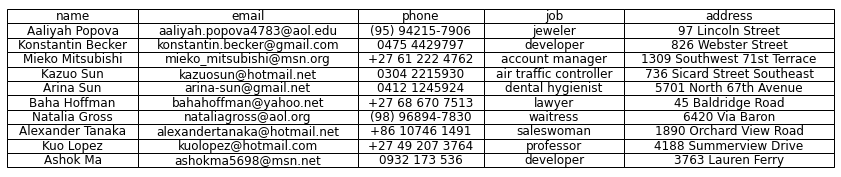

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Example data: If using a CSV, replace this with pd.read_csv('yourfile.csv')
# Replace this with actual data if needed
# data = {
#     'name': ['', '', '', '', '', '', '', '', '', ''],
#     'email': ['', '', '', '', '', '', '', '', '', ''],
#     'phone': ['', '', '', '', '', '', '', '', '', ''],
#     'job': ['', '', '', '', '', '', '', '', '', ''],
#     'address': ['', '', '', '', '', '', '', '', '', ''],
# }

# # Create a DataFrame
# df = pd.DataFrame(data)

df = df3
# Plotting the DataFrame as a table
fig, ax = plt.subplots(figsize=(10, 3))  # Adjust the figure size as needed
ax.axis('off')  # Hide the axis

# Create table from DataFrame
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)  # Scale the table for better fit
table.auto_set_column_width(col=[0, 1, 2, 3, 4])  # Adjust column widths

plt.show()
# Save the table as an image
#plt.savefig('table_image.png', bbox_inches='tight', pad_inches=0.1)

# Display the saved image
#img = Image.open('table_image.png')
#img.show()

In [22]:
os.makedirs('./data/pii_img/')

In [ ]:
# batch dataset generation
n = 10 # create a table every n lines
total_nums = df2.shape[0]//n
print(total_nums)
path = './data/pii_img/'

for i in range(total_nums):
    df3 = df2[['name','email','phone','job','address']][int(n*i):int(n*i+n)]
    df = df3
    # Plotting the DataFrame as a table
    fig, ax = plt.subplots(figsize=(10, 3))  # Adjust the figure size as needed
    ax.axis('off')  # Hide the axis

    # Create table from DataFrame
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.2)  # Scale the table for better fit
    table.auto_set_column_width(col=[0, 1, 2, 3, 4])  # Adjust column widths

    #plt.show()
    # Save the table as an image
    plt.savefig(path + 'img_'+str(i)+'.png', bbox_inches='tight', pad_inches=0.1)
    
    # Display the saved image
    #img = Image.open('table_image.png')
    #img.show()

### CelebA Table Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

new_path = './data/celebatable/'
path = "./data/celeba/img_align_celeba/"
fnames = os.listdir(path)
i=0
for fn in fnames[:1000]:
    # Load the existing image (adjust the path as needed)
    left_image_path =  "./data/celeba/img_align_celeba/" + fn
    left_image = Image.open(left_image_path)

    # Create sample data for the table
    np.random.seed(i)
    np.random.randint(df2.shape[0])
    cdf = df2.loc[i]
    data = {
        'Column 1': ['Name: ','Email: ','Phone: ','Occupation: ','Address: '],
        'Column 2': [cdf['name'],cdf['email'],cdf['phone'],cdf['job'],cdf['address']]
    }

    # Create DataFrame
    df = pd.DataFrame(data)

    # Create the table image using Matplotlib
    fig, ax = plt.subplots(figsize=(4, 2))  # Adjust size to fit the height of the existing image
    ax.axis('tight')
    ax.axis('off')
    ax.table(cellText=df.values, cellLoc='center', loc='center')

    # Save the table as an image temporarily
    table_image_path = "table_image.png"
    plt.savefig(table_image_path, bbox_inches='tight', dpi=300)
    plt.close()

    # Load the saved table image
    table_image = Image.open(table_image_path)
    w,h = table_image.size
    #print(w,h)
    # Resize the table image to match the height of the existing image (218 pixels high)
    table_image = table_image.resize((int(h/218*178), 218))  # Width adjusted to keep proportions reasonable

    # Determine the size of the final combined image
    total_width = left_image.width + table_image.width
    max_height = max(left_image.height, table_image.height)

    # Create a new blank image with the combined size
    combined_image = Image.new("RGB", (total_width, max_height), "white")

    # Paste the left image and table image side by side
    combined_image.paste(left_image, (0, 0))
    combined_image.paste(table_image, (left_image.width, 0))

    # Save the final combined image
    combined_image.save(new_path + str(i)+".png")
    #combined_image.show()
    i+=1

### Demonstration Dataset Generation

In [ ]:
df2 = pd.read_csv('./data/pii_dataset.csv')

In [158]:
#ids = []
filtered_sentences = []
for i in range(df2.shape[0]):  #
    sentences = df2.loc[i,'text'].split('. ')
    slen = [len(s.split(' ')) for s in sentences]
    #print(sum(slen))
    tks = eval(df2.loc[i,'tokens'])
    labels = eval(df2.loc[i,'labels'])
    job = df2.loc[i,'job']
    #print(len(tks))
    #group tokens by sentences
    loc = 0
    
    for j,sl in enumerate(slen):
        c_sentence = sentences[j]
        #print(tks[loc:loc+j])
        lbls = labels[loc:loc+sl]
        if len(set(lbls))!=1:  #contain sensitive information
            filtered_sentences.append(c_sentence)
#         elif job in c_sentence:  
#             filtered_sentences.append(c_sentence)
        loc+=sl
    
    # check if lens agree
#     if sum(slen) != len(tks):
#         print(i)    
    
#     job = df2.loc[i,'job']
#     if job not in sentences[0]:
#         ids.append(i)

In [162]:
# Create demonstration dataset
df_new = pd.DataFrame.from_dict({'statements':filtered_sentences})
df_new.to_csv('./data/pii_sentences.csv')